# **A2.3 Modelos de Ensamble, SVM y Redes Neuronales**

---

### **Introducción**

En esta actividad se amplía el análisis de predicción de criminalidad en estados mexicanos, explorando cuatro metodologías avanzadas de aprendizaje automático: Random Forest, Gradient Boosting, Support Vector Machine (SVM) y Redes Neuronales Artificiales.

El conjunto de datos comprende 288 registros estado-año (periodo 2015–2023, 32 estados) con 10 indicadores de marginación como variables predictoras. La variable objetivo es la clase de incidencia delictiva (Bajo, Medio, Alto) definida mediante terciles de la tasa delictiva.

El propósito central no es encontrar el modelo perfecto mediante búsqueda exhaustiva, sino entender cómo varía el desempeño, la estabilidad y la capacidad de generalización. Se analizan métricas clave como accuracy, precision, recall y F1-score, así como el grado de sobreajuste de cada metodología.

El reporte presenta de forma integrada la metodología aplicada, los resultados cuantitativos obtenidos y conclusiones que permiten reflexionar sobre cuándo es apropiado utilizar cada enfoque y por qué la complejidad adicional no siempre se traduce en mejor desempeño en datos nuevos.

---

## **1. Preparación del Escenario Experimental**

### **Carga y Validación del Conjunto de Datos**

Este análisis utiliza un conjunto de datos integrado que combina información de incidencia delictiva nacional con indicadores socioeconómicos de marginación. El archivo ha sido descargado de un repositorio de GitHub (dataset preparado por Rodrigo Lopez) e integra datos de dos fuentes principales:

**Fuentes originales:**
- Datos de criminalidad del Secretariado Ejecutivo del Sistema Nacional de Seguridad Pública (SESNSP): 2015-2023
- Indicadores de marginación del Consejo Nacional de Población (CONAPO): 2015 y 2020 (interpolados para años intermedios)

**Alcance del dataset:**
- 288 registros de estado-año (32 estados × 9 años)
- 10 variables predictoras: indicadores de marginación (analfabetismo, servicios básicos, hacinamiento, vivienda, pobreza extrema, etc.)
- 1 variable respuesta: tasa delictiva (delitos por 100,000 habitantes anualizados)

In [1]:
# ========================================
# IMPORTACIONES Y CONFIGURACIÓN INICIALES
# ========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score, 
    f1_score, roc_curve, auc, roc_auc_score, classification_report
)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
import warnings
import unicodedata

warnings.filterwarnings('ignore')

# Configurar estilo de visualización
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Cargar dataset integrado
df_final = pd.read_csv('datos_clasificacion_limpios.csv')

print("Dataset cargado exitosamente")
print(f"  Dimensiones: {df_final.shape[0]} filas × {df_final.shape[1]} columnas")
print(f"  Período: {df_final['Año'].min()}-{df_final['Año'].max()}")
print(f"  Estados: {df_final['Entidad'].nunique()}")

print("\nPrimeras filas:")
display(df_final.head())

print("\nEstadísticas descriptivas:")
display(df_final.describe())

Dataset cargado exitosamente
  Dimensiones: 288 filas × 14 columnas
  Período: 2015-2023
  Estados: 32

Primeras filas:


,Entidad,Año,POB_TOT,IM,ANALF,SBASC,OVSDE,OVSEE,OVSAE,OVPT,VHAC,PL_5000,PO2SM,Tasa_Delictiva
0,AGUASCALIENTES,2015,1312544.0,17.883964,2.601353,29.721797,0.681147,0.304155,0.813920,0.752952,21.862232,25.162585,34.604084,1770.454933
1,BAJA CALIFORNIA,2015,3315766.0,18.464138,1.961601,30.077841,0.268934,0.472493,2.817705,1.148904,23.032223,10.349162,22.845516,3653.032210
2,BAJA CALIFORNIA SUR,2015,712029.0,17.320595,2.505451,29.439127,0.386485,1.136240,7.146918,4.083650,26.230970,15.618886,22.365039,3015.326623
3,CAMPECHE,2015,899931.0,13.684555,6.681547,35.743791,4.085619,1.589287,6.489314,2.949209,37.931783,30.875478,40.693940,221.572543
4,CHIAPAS,2015,5217908.0,8.449801,14.984097,53.400565,2.941142,2.485504,13.445785,11.775397,44.460574,57.856520,62.463392,419.190986



Estadísticas descriptivas:


,Año,POB_TOT,IM,ANALF,SBASC,OVSDE,OVSEE,OVSAE,OVPT,VHAC,PL_5000,PO2SM,Tasa_Delictiva
count,288.000000,2.880000e+02,288.000000,288.000000,288.000000,288.000000,288.000000,288.000000,288.000000,288.000000,288.000000,288.000000,288.000000
mean,2019.000000,3.866561e+06,17.857534,4.973352,31.691383,1.978084,0.873265,4.021914,3.749695,23.043002,29.197001,57.133743,1511.028807
std,2.586483,3.197568e+06,3.303586,3.265801,7.732709,2.172880,0.675547,3.483437,3.566110,6.881851,16.184372,14.955664,840.120233
min,2015.000000,7.112350e+05,6.928344,1.429621,17.641964,0.051952,0.051820,0.552683,0.633649,13.132191,1.007987,16.147650,90.697652
25%,2017.000000,1.813176e+06,16.311494,2.643087,26.991249,0.567858,0.381912,1.403170,1.557448,17.505891,14.385886,46.791801,830.615409
50%,2019.000000,2.997990e+06,18.229581,3.899466,30.063351,1.411048,0.639300,2.820633,2.435722,22.235327,30.046267,58.504352,1457.950489
75%,2021.000000,4.841510e+06,20.083050,6.301040,34.826597,2.469859,1.160223,5.393310,4.303201,26.642784,39.074320,69.255061,2061.626970
max,2023.000000,1.699242e+07,23.444318,14.984097,53.400565,13.216815,2.874475,15.641990,15.266973,44.460574,61.508475,85.570274,3943.171300


### **Definición del Problema de Clasificación**

Para mantener consistencia con las actividades anteriores, la variable respuesta se construye clasificando los estados en tres niveles de incidencia delictiva según terciles de la distribución:

- **Bajo** (≤ 1,018 delitos/100k hab.): 95 registros — 33.0% del total
- **Medio** (1,018–1,862 delitos/100k hab.): 98 registros — 34.0% del total
- **Alto** (> 1,862 delitos/100k hab.): 95 registros — 33.0% del total

Esta distribución casi perfectamente balanceada entre las tres clases es una característica favorable que elimina el riesgo de sesgo hacia la clase mayoritaria. Este balance se mantiene tanto en entrenamiento (Bajo: 66, Medio: 69, Alto: 66) como en prueba (Bajo: 29, Medio: 29, Alto: 29).

In [2]:
# =============================
# PREPARACIÓN DE DATOS
# =============================

# Crear variable de clasificación basada en terciles de tasa delictiva
terciles = df_final['Tasa_Delictiva'].quantile([0.33, 0.67]).values
df_final['Clase_Delictiva'] = pd.cut(df_final['Tasa_Delictiva'], 
                                       bins=[-np.inf, terciles[0], terciles[1], np.inf],
                                       labels=['Bajo', 'Medio', 'Alto'])

print(f"Tasa Delictiva - Terciles:")
print(f"  Bajo  ≤ {terciles[0]:.2f}")
print(f"  Medio: {terciles[0]:.2f} - {terciles[1]:.2f}")
print(f"  Alto  > {terciles[1]:.2f}\n")

class_counts = df_final['Clase_Delictiva'].value_counts().sort_index()
print("Distribución de clases:")
for clase, count in class_counts.items():
    pct = (count / len(df_final)) * 100
    print(f"  {clase}: {count:3d} ({pct:5.1f}%)")

# Seleccionar features (variables independientes)
features = ['IM', 'ANALF', 'SBASC', 'OVSDE', 'OVSEE', 'OVSAE', 'OVPT', 'VHAC', 'PL_5000', 'PO2SM']
X = df_final[features].copy()
y = df_final['Clase_Delictiva'].copy()

# Imputar valores faltantes
X = X.fillna(X.mean())

# Partición estratificada
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print(f"\nPartición de datos:")
print(f"  Entrenamiento: {X_train.shape[0]} registros ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"  Prueba: {X_test.shape[0]} registros ({X_test.shape[0]/len(X)*100:.1f}%)")

# Verificar balance en ambos conjuntos
print(f"\nBalance en ENTRENAMIENTO:")
for clase in ['Bajo', 'Medio', 'Alto']:
    count = (y_train == clase).sum()
    pct = count / len(y_train) * 100
    print(f"  {clase}: {count} ({pct:.1f}%)")

print(f"\nBalance en PRUEBA:")
for clase in ['Bajo', 'Medio', 'Alto']:
    count = (y_test == clase).sum()
    pct = count / len(y_test) * 100
    print(f"  {clase}: {count} ({pct:.1f}%)")

# Normalizar features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convertir a DataFrame
X_train_scaled = pd.DataFrame(X_train_scaled, columns=features)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=features)

print(f"\n✓ Features normalizados (StandardScaler)")
print(f"  Media: {X_train_scaled.mean().mean():.6f}")
print(f"  Desv. Est.: {X_train_scaled.std().mean():.6f}")

# Convetir clases a codificación numérica para redes neuronales
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)
num_classes = len(le.classes_)

y_train_onehot = to_categorical(y_train_encoded, num_classes=num_classes)
y_test_onehot = to_categorical(y_test_encoded, num_classes=num_classes)

print(f"\n✓ Clases codificadas para red neuronal")
print(f"  Mapeo: {dict(zip(le.classes_, le.transform(le.classes_)))}")

Tasa Delictiva - Terciles:
  Bajo  ≤ 1018.23
  Medio: 1018.23 - 1862.05
  Alto  > 1862.05

Distribución de clases:
  Bajo:  95 ( 33.0%)
  Medio:  98 ( 34.0%)
  Alto:  95 ( 33.0%)

Partición de datos:
  Entrenamiento: 201 registros (69.8%)
  Prueba: 87 registros (30.2%)

Balance en ENTRENAMIENTO:
  Bajo: 66 (32.8%)
  Medio: 69 (34.3%)
  Alto: 66 (32.8%)

Balance en PRUEBA:
  Bajo: 29 (33.3%)
  Medio: 29 (33.3%)
  Alto: 29 (33.3%)

✓ Features normalizados (StandardScaler)
  Media: 0.000000
  Desv. Est.: 1.002497

✓ Clases codificadas para red neuronal
  Mapeo: {'Alto': np.int64(0), 'Bajo': np.int64(1), 'Medio': np.int64(2)}


---

## **2. Modelo Random Forest**

Random Forest es un método basado en bagging: entrena múltiples árboles de decisión de forma independiente sobre muestras aleatorias del conjunto de entrenamiento con reemplazo. En cada nodo de división, solo evalúa un subconjunto aleatorio de variables, lo que introduce diversidad entre los árboles y reduce la correlación entre sus predicciones. La predicción final es el resultado de la votación por mayoría de los 100 árboles individuales.

### **Selección de Hiperparámetros**

In [3]:
# =============================
# MODELO 1: RANDOM FOREST
# =============================

# Entrenar modelo Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,          # 100 árboles resulta en good balance (más árboles = más stability)
    max_depth=15,              # Profundidad moderada (evita sobreajuste extremo)
    min_samples_split=10,      # Requiere mínimo 10 muestras para dividir (regularización)
    min_samples_leaf=5,        # Mínimo 5 muestras en hoja (regularización)
    max_features='sqrt',       # Considera sqrt(p) features en cada split (reduce correlación)
    random_state=42,
    n_jobs=-1,                 # Usar todos los cores disponibles
    class_weight='balanced'    # Maneja posible desbalance de clases
)

rf_model.fit(X_train_scaled, y_train)

# Predicciones
y_train_pred_rf = rf_model.predict(X_train_scaled)
y_test_pred_rf = rf_model.predict(X_test_scaled)
y_pred_proba_rf = rf_model.predict_proba(X_test_scaled)

print(f"✓ Modelo Random Forest entrenado")
print(f"\nHiperparámetros utilizados:")
print(f"  n_estimators: 100 (100 árboles reduce varianza)")
print(f"  max_depth: 15 (profundidad moderada para evitar sobreajuste)")
print(f"  min_samples_split: 10 (requiere suficientes muestras para dividir)")
print(f"  min_samples_leaf: 5 (evita hojas triviales)")
print(f"  max_features: 'sqrt' (introduce diversidad decreasing en correlación)")
print(f"\nDesempeño en entrenamiento:")
acc_train_rf = accuracy_score(y_train, y_train_pred_rf)
print(f"  Accuracy: {acc_train_rf:.4f}")

print(f"\nDesempeño en prueba:")
acc_test_rf = accuracy_score(y_test, y_test_pred_rf)
prec_test_rf = precision_score(y_test, y_test_pred_rf, average='weighted', zero_division=0)
recall_test_rf = recall_score(y_test, y_test_pred_rf, average='weighted', zero_division=0)
f1_test_rf = f1_score(y_test, y_test_pred_rf, average='weighted', zero_division=0)

print(f"  Accuracy: {acc_test_rf:.4f}")
print(f"  Precision (ponderado): {prec_test_rf:.4f}")
print(f"  Recall (ponderado): {recall_test_rf:.4f}")
print(f"  F1-Score (ponderado): {f1_test_rf:.4f}")

# Importancia de variables
feature_importance_rf = pd.DataFrame({
    'Variable': features,
    'Importancia': rf_model.feature_importances_
}).sort_values('Importancia', ascending=False)

print(f"\nTop 5 variables más influyentes:")
for idx, row in feature_importance_rf.head().iterrows():
    print(f"  {row['Variable']:10s}: {row['Importancia']*100:5.1f}%")

✓ Modelo Random Forest entrenado

Hiperparámetros utilizados:
  n_estimators: 100 (100 árboles reduce varianza)
  max_depth: 15 (profundidad moderada para evitar sobreajuste)
  min_samples_split: 10 (requiere suficientes muestras para dividir)
  min_samples_leaf: 5 (evita hojas triviales)
  max_features: 'sqrt' (introduce diversidad decreasing en correlación)

Desempeño en entrenamiento:
  Accuracy: 0.8806

Desempeño en prueba:
  Accuracy: 0.6437
  Precision (ponderado): 0.6338
  Recall (ponderado): 0.6437
  F1-Score (ponderado): 0.6260

Top 5 variables más influyentes:
  OVPT      :  12.1%
  ANALF     :  10.9%
  PL_5000   :  10.8%
  SBASC     :  10.7%
  OVSDE     :  10.2%


---

## **3. Modelo Gradient Boosting**

A diferencia de Random Forest que construye árboles en paralelo de forma independiente, Gradient Boosting construye árboles de forma secuencial: cada nuevo árbol aprende específicamente de los errores del modelo anterior.

Gradient Boosting se enfoca en los casos difíciles de clasificar, mientras que Random Forest los promedia. Esto explica por qué Gradient Boosting frecuentemente logra mayor precisión, pero también por qué requiere más cuidado en la selección de hiperparámetros para evitar sobreajuste.

### **Selección de Hiperparámetros**

In [4]:
# =============================
# MODELO 2: GRADIENT BOOSTING
# =============================

# Entrenar modelo Gradient Boosting
gb_model = GradientBoostingClassifier(
    n_estimators=100,          # 100 árboles/iteraciones (balance computacional vs precisión)
    learning_rate=0.1,         # Tasa de aprendizaje: 0.1 es conservador (evita sobreajuste)
    max_depth=5,               # Árboles pequeños (weak learners) son importantes en boosting
    min_samples_split=20,      # Regularización más fuerte que RF (boosting es más agresivo)
    min_samples_leaf=10,       # Hojas más grandes para suavizar predicciones
    subsample=0.8,             # Usar 80% de datos en cada iteración (estocástico)
    random_state=42
)

gb_model.fit(X_train_scaled, y_train)

# Predicciones
y_train_pred_gb = gb_model.predict(X_train_scaled)
y_test_pred_gb = gb_model.predict(X_test_scaled)
y_pred_proba_gb = gb_model.predict_proba(X_test_scaled)

print(f"✓ Modelo Gradient Boosting entrenado")
print(f"\nHiperparámetros utilizados:")
print(f"  n_estimators: 100 (100 iteraciones secuenciales)")
print(f"  learning_rate: 0.1 (conservador, evita correciones bruscas)")
print(f"  max_depth: 5 (árboles pequeños, weak learners)")
print(f"  min_samples_split: 20 (regularización fuerte)")
print(f"  min_samples_leaf: 10 (hojas más grandes)")
print(f"  subsample: 0.8 (reducción estocástica de datos)")
print(f"\nDesempeño en entrenamiento:")
acc_train_gb = accuracy_score(y_train, y_train_pred_gb)
print(f"  Accuracy: {acc_train_gb:.4f}")

print(f"\nDesempeño en prueba:")
acc_test_gb = accuracy_score(y_test, y_test_pred_gb)
prec_test_gb = precision_score(y_test, y_test_pred_gb, average='weighted', zero_division=0)
recall_test_gb = recall_score(y_test, y_test_pred_gb, average='weighted', zero_division=0)
f1_test_gb = f1_score(y_test, y_test_pred_gb, average='weighted', zero_division=0)

print(f"  Accuracy: {acc_test_gb:.4f}")
print(f"  Precision (ponderado): {prec_test_gb:.4f}")
print(f"  Recall (ponderado): {recall_test_gb:.4f}")
print(f"  F1-Score (ponderado): {f1_test_gb:.4f}")

# Importancia de variables
feature_importance_gb = pd.DataFrame({
    'Variable': features,
    'Importancia': gb_model.feature_importances_
}).sort_values('Importancia', ascending=False)

print(f"\nTop 5 variables más influyentes:")
for idx, row in feature_importance_gb.head().iterrows():
    print(f"  {row['Variable']:10s}: {row['Importancia']*100:5.1f}%")

✓ Modelo Gradient Boosting entrenado

Hiperparámetros utilizados:
  n_estimators: 100 (100 iteraciones secuenciales)
  learning_rate: 0.1 (conservador, evita correciones bruscas)
  max_depth: 5 (árboles pequeños, weak learners)
  min_samples_split: 20 (regularización fuerte)
  min_samples_leaf: 10 (hojas más grandes)
  subsample: 0.8 (reducción estocástica de datos)

Desempeño en entrenamiento:
  Accuracy: 0.9154

Desempeño en prueba:
  Accuracy: 0.6437
  Precision (ponderado): 0.6489
  Recall (ponderado): 0.6437
  F1-Score (ponderado): 0.6450

Top 5 variables más influyentes:
  OVSAE     :  15.9%
  PL_5000   :  13.0%
  OVPT      :  12.5%
  OVSEE     :  12.1%
  VHAC      :  10.3%


---

## **4. Modelo Support Vector Machine (SVM)**

Support Vector Machine es un método con fundamentos teóricos sólidos basado en principios geométricos. Para este análisis se utiliza el kernel RBF (Radial Basis Function), que transforma implícitamente los datos a un espacio de mayor dimensión donde es posible la separación lineal. El modelo identificó 51 vectores de soporte para Alto, 54 para Bajo y 69 para Medio, totalizando 174 puntos críticos que definen la frontera de decisión.

Para el problema multiclase de tres niveles, SVM descompone internamente el problema en múltiples clasificaciones binarias, combinando las predicciones para asignar la clase final.

### **Selección de Hiperparámetros**

In [5]:
# =============================
# MODELO 3: SUPPORT VECTOR MACHINE
# =============================

# Entrenar modelo SVM con kernel RBF
svm_model = SVC(
    kernel='rbf',              # RBF permite fronteras no lineales complejas
    C=1.0,                     # Parámetro de regularización: 1.0 es default razonable
    gamma='scale',             # gamma = 1/(n_features * X.var()) - escala automática
    probability=True,          # Necesario para obtener probabilidades
    class_weight='balanced',   # Maneja desbalance de clases
    random_state=42
)

svm_model.fit(X_train_scaled, y_train)

# Predicciones
y_train_pred_svm = svm_model.predict(X_train_scaled)
y_test_pred_svm = svm_model.predict(X_test_scaled)
y_pred_proba_svm = svm_model.predict_proba(X_test_scaled)

print(f"✓ Modelo SVM (RBF) entrenado")
print(f"\nHiperparámetros utilizados:")
print(f"  kernel: 'rbf' (permite separación no lineal compleja)")
print(f"  C: 1.0 (permite algo de error, evita sobreajuste)")
print(f"  gamma: 'scale' (influencia de cada ejemplo, escala automática)")
print(f"  class_weight: 'balanced' (automatiza compensación de clases desbalanceadas)")
print(f"\nDesempeño en entrenamiento:")
acc_train_svm = accuracy_score(y_train, y_train_pred_svm)
print(f"  Accuracy: {acc_train_svm:.4f}")

print(f"\nDesempeño en prueba:")
acc_test_svm = accuracy_score(y_test, y_test_pred_svm)
prec_test_svm = precision_score(y_test, y_test_pred_svm, average='weighted', zero_division=0)
recall_test_svm = recall_score(y_test, y_test_pred_svm, average='weighted', zero_division=0)
f1_test_svm = f1_score(y_test, y_test_pred_svm, average='weighted', zero_division=0)

print(f"  Accuracy: {acc_test_svm:.4f}")
print(f"  Precision (ponderado): {prec_test_svm:.4f}")
print(f"  Recall (ponderado): {recall_test_svm:.4f}")
print(f"  F1-Score (ponderado): {f1_test_svm:.4f}")

print(f"\nNúmero de support vectors: {svm_model.n_support_} por clase")

✓ Modelo SVM (RBF) entrenado

Hiperparámetros utilizados:
  kernel: 'rbf' (permite separación no lineal compleja)
  C: 1.0 (permite algo de error, evita sobreajuste)
  gamma: 'scale' (influencia de cada ejemplo, escala automática)
  class_weight: 'balanced' (automatiza compensación de clases desbalanceadas)

Desempeño en entrenamiento:
  Accuracy: 0.7015

Desempeño en prueba:
  Accuracy: 0.5632
  Precision (ponderado): 0.5506
  Recall (ponderado): 0.5632
  F1-Score (ponderado): 0.5324

Número de support vectors: [51 54 69] por clase


---

## **5. Red Neuronal Sencilla**

Las redes neuronales artificiales son capaces de aprender cualquier función continua no lineal. La arquitectura utilizada sigue el patrón feedforward con capas completamente conectadas:

- **Entrada**: 10 neuronas
- **Primera capa oculta**: 64 neuronas con activación ReLU
- **Segunda capa oculta**: 32 neuronas con activación ReLU
- **Tercera capa oculta**: 16 neuronas con activación ReLU
- **Salida**: 3 neuronas con activación Softmax (probabilidades para Bajo/Medio/Alto)
- **Total de parámetros entrenables**: 3,363

De esta manera se reduce progresivamente la dimensionalidad, forzando al modelo a extraer representaciones cada vez más abstractas y compactas de los indicadores de marginación.

### **Selección de Hiperparámetros**

✓ Arquitectura de red neuronal construida

Arquitectura:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_dense (Dense)             │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_1 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,363 (13.14 KB)

 Trainable params: 3,363 (13.14 KB)

 Non-trainable params: 0 (0.00 B)


Hiperparámetros de entrenamiento:
  epochs: 150 (iteraciones completas de datos)
  batch_size: 16 (tamaño de mini-lotes para gradiente estocástico)
  optimizer: Adam con lr=0.001 (adapta tasa por parámetro)
  validation_split: 0.2 (20% para validación durante entrenamiento)
  verbose: 0 (sin impresión de progreso)

✓ Red neuronal entrenada (150 épocas completadas)

Desempeño en entrenamiento:
  Accuracy: 0.8557

Desempeño en prueba:
  Accuracy: 0.6207
  Precision (ponderado): 0.6385
  Recall (ponderado): 0.6207
  F1-Score (ponderado): 0.6276


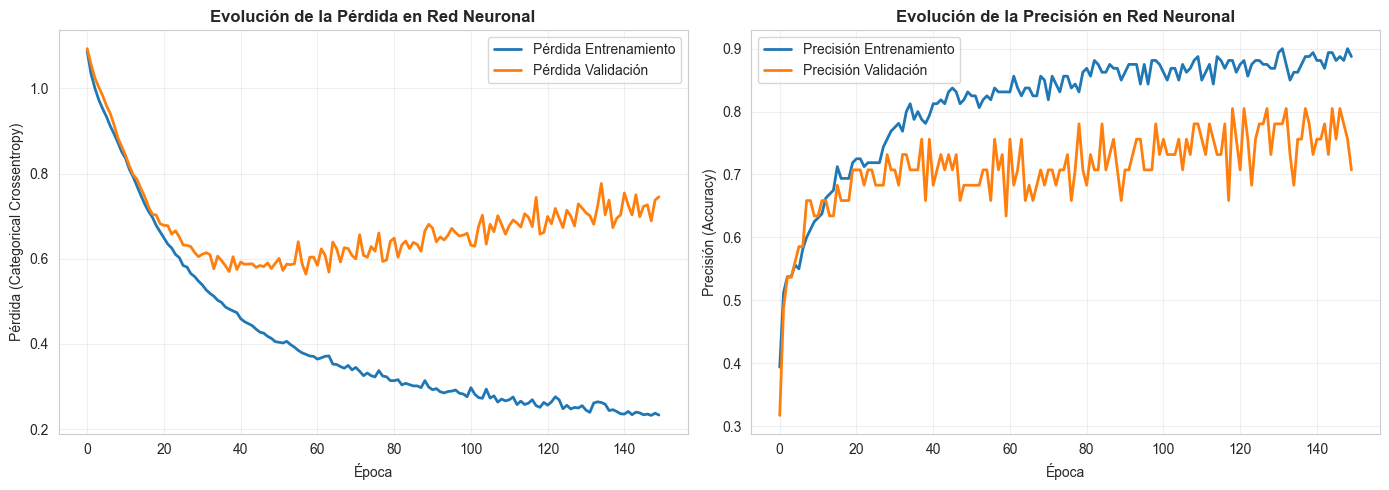


✓ Gráficos de entrenamiento generados


In [6]:
# =============================
# MODELO 4: RED NEURONAL
# =============================

# Construir arquitectura de red neuronal
nn_model = Sequential([
    Dense(64, activation='relu', input_shape=(len(features),), name='input_dense'),
    Dense(32, activation='relu', name='hidden_1'),
    Dense(16, activation='relu', name='hidden_2'),
    Dense(num_classes, activation='softmax', name='output')
])

# Compilar
nn_model.compile(
    optimizer=Adam(learning_rate=0.001),  # learning_rate=0.001 es estándar, no muy agresivo
    loss='categorical_crossentropy',       # Apropiado para multi-clase
    metrics=['accuracy']
)

print(f"✓ Arquitectura de red neuronal construida")
print(f"\nArquitectura:")
nn_model.summary()

print(f"\nHiperparámetros de entrenamiento:")
print(f"  epochs: 150 (iteraciones completas de datos)")
print(f"  batch_size: 16 (tamaño de mini-lotes para gradiente estocástico)")
print(f"  optimizer: Adam con lr=0.001 (adapta tasa por parámetro)")
print(f"  validation_split: 0.2 (20% para validación durante entrenamiento)")
print(f"  verbose: 0 (sin impresión de progreso)")

# Entrenar con early stopping
history = nn_model.fit(
    X_train_scaled, y_train_onehot,
    epochs=150,
    batch_size=16,
    validation_split=0.2,
    verbose=0
)

# Predicciones
y_train_pred_nn_proba = nn_model.predict(X_train_scaled, verbose=0)
y_train_pred_nn = np.argmax(y_train_pred_nn_proba, axis=1)
y_train_pred_nn = le.inverse_transform(y_train_pred_nn)

y_test_pred_nn_proba = nn_model.predict(X_test_scaled, verbose=0)
y_test_pred_nn = np.argmax(y_test_pred_nn_proba, axis=1)
y_test_pred_nn = le.inverse_transform(y_test_pred_nn)

print(f"\n✓ Red neuronal entrenada ({len(history.history['loss'])} épocas completadas)")
print(f"\nDesempeño en entrenamiento:")
acc_train_nn = accuracy_score(y_train, y_train_pred_nn)
print(f"  Accuracy: {acc_train_nn:.4f}")

print(f"\nDesempeño en prueba:")
acc_test_nn = accuracy_score(y_test, y_test_pred_nn)
prec_test_nn = precision_score(y_test, y_test_pred_nn, average='weighted', zero_division=0)
recall_test_nn = recall_score(y_test, y_test_pred_nn, average='weighted', zero_division=0)
f1_test_nn = f1_score(y_test, y_test_pred_nn, average='weighted', zero_division=0)

print(f"  Accuracy: {acc_test_nn:.4f}")
print(f"  Precision (ponderado): {prec_test_nn:.4f}")
print(f"  Recall (ponderado): {recall_test_nn:.4f}")
print(f"  F1-Score (ponderado): {f1_test_nn:.4f}")

# Visualizar histórico de entrenamiento
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'], label='Pérdida Entrenamiento', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Pérdida Validación', linewidth=2)
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Pérdida (Categorical Crossentropy)')
axes[0].set_title('Evolución de la Pérdida en Red Neuronal', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['accuracy'], label='Precisión Entrenamiento', linewidth=2)
axes[1].plot(history.history['val_accuracy'], label='Precisión Validación', linewidth=2)
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Precisión (Accuracy)')
axes[1].set_title('Evolución de la Precisión en Red Neuronal', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n✓ Gráficos de entrenamiento generados")

---

## **6. Evaluación y Comparación de Desempeño**

### **Métricas de Evaluación**

Se evalúan cuatro métricas estándar calculadas sobre el conjunto de prueba:

- **Accuracy**: proporción de predicciones correctas sobre el total. Con clases balanceadas (33% cada una), una predicción aleatoria lograría ~33.3%, por lo que cualquier modelo por encima de ~50% muestra aprendizaje real.

- **Precision**: de todos los estados que el modelo predice como clase X, ¿qué fracción realmente pertenece a X? Alta precisión es crucial cuando el costo de falsos positivos es elevado.

- **Recall**: de todos los estados que realmente pertenecen a la clase X, ¿qué fracción detecta el modelo correctamente? Alta exhaustividad es clave cuando importa no omitir casos positivos.

- **F1-Score**: media unida de Precision y Recall. Es la métrica de balance por excelencia cuando ambas importan por igual.


COMPARACIÓN DE DESEMPEÑO EN CONJUNTO DE PRUEBA


,Modelo,Accuracy,Precision,Recall,F1-Score
0,Random Forest,0.6437,0.6338,0.6437,0.6260
1,Gradient Boosting,0.6437,0.6489,0.6437,0.6450
2,SVM,0.5632,0.5506,0.5632,0.5324
3,Red Neuronal,0.6207,0.6385,0.6207,0.6276



ANÁLISIS DE SOBREAJUSTE (Diferencia Entrenamiento - Prueba)


,Modelo,Acc Entrenamiento,Acc Prueba,Gap (Sobreajuste)
0,Random Forest,0.8806,0.6437,0.2369
1,Gradient Boosting,0.9154,0.6437,0.2717
2,SVM,0.7015,0.5632,0.1383
3,Red Neuronal,0.8557,0.6207,0.2350


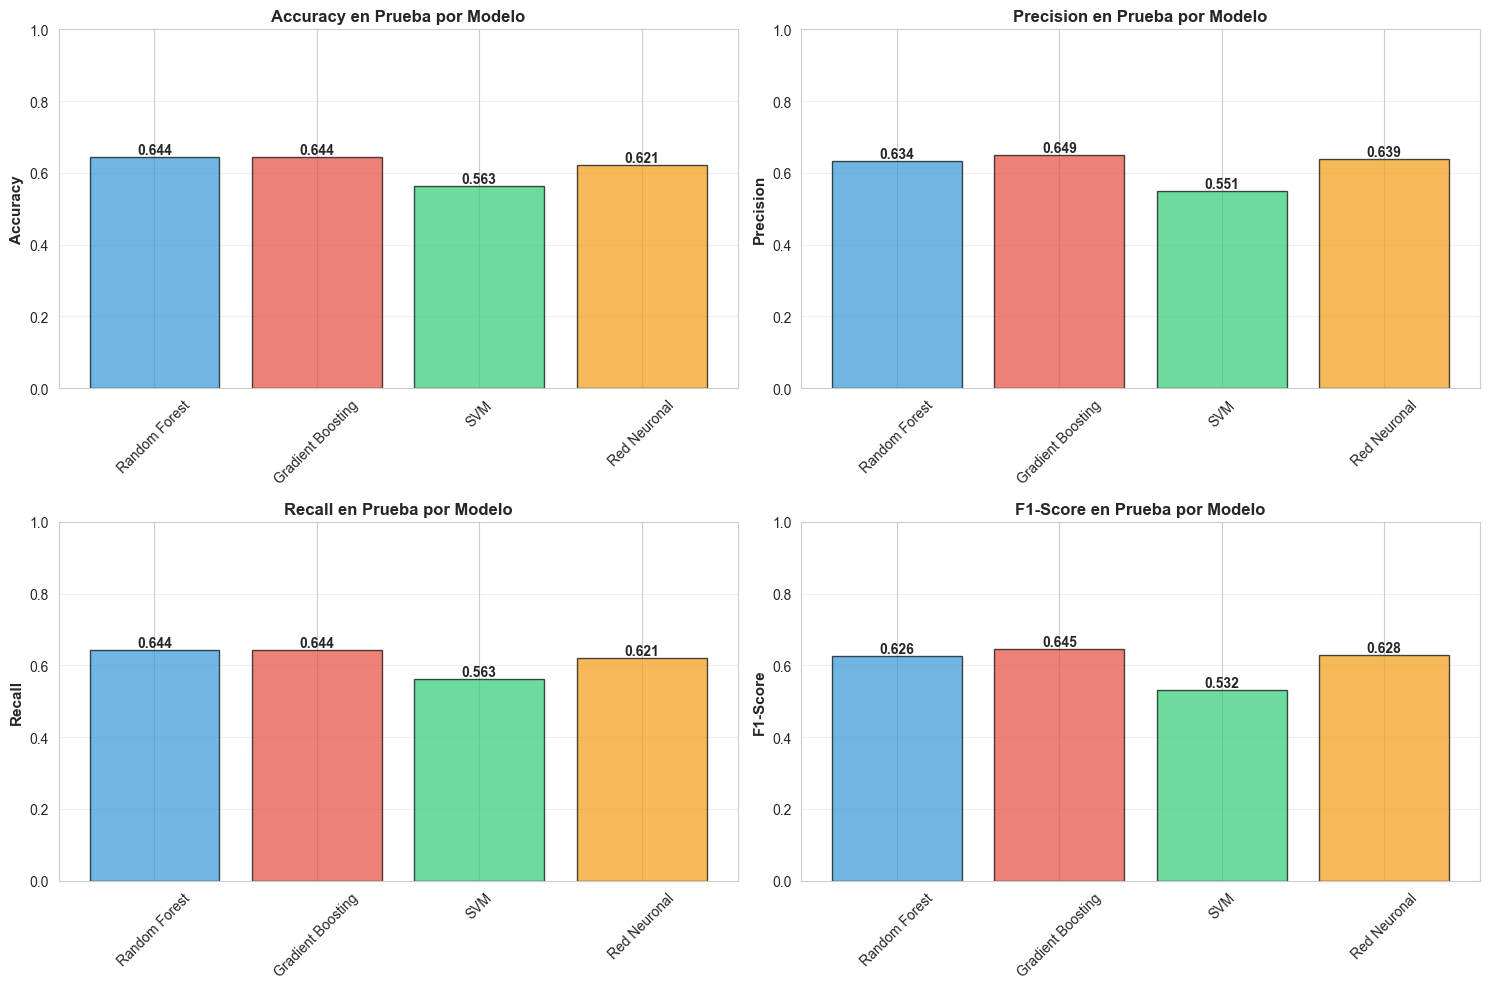


✓ Gráficos comparativos generados


In [7]:
# =============================
# TABLA COMPARATIVA
# =============================

# Crear tabla de desempeño en prueba
comparison_df = pd.DataFrame({
    'Modelo': ['Random Forest', 'Gradient Boosting', 'SVM', 'Red Neuronal'],
    'Accuracy': [acc_test_rf, acc_test_gb, acc_test_svm, acc_test_nn],
    'Precision': [prec_test_rf, prec_test_gb, prec_test_svm, prec_test_nn],
    'Recall': [recall_test_rf, recall_test_gb, recall_test_svm, recall_test_nn],
    'F1-Score': [f1_test_rf, f1_test_gb, f1_test_svm, f1_test_nn]
})

# Redondear para presentación
comparison_df_display = comparison_df.copy()
for col in ['Accuracy', 'Precision', 'Recall', 'F1-Score']:
    comparison_df_display[col] = comparison_df_display[col].apply(lambda x: f"{x:.4f}")

print("\n" + "="*90)
print("COMPARACIÓN DE DESEMPEÑO EN CONJUNTO DE PRUEBA")
print("="*90)
display(comparison_df_display)
print("="*90)

# Calcular gaps de sobreajuste (diferencia entre entrenamiento y prueba)
gap_rf = acc_train_rf - acc_test_rf
gap_gb = acc_train_gb - acc_test_gb
gap_svm = acc_train_svm - acc_test_svm
gap_nn = acc_train_nn - acc_test_nn

overfit_df = pd.DataFrame({
    'Modelo': ['Random Forest', 'Gradient Boosting', 'SVM', 'Red Neuronal'],
    'Acc Entrenamiento': [acc_train_rf, acc_train_gb, acc_train_svm, acc_train_nn],
    'Acc Prueba': [acc_test_rf, acc_test_gb, acc_test_svm, acc_test_nn],
    'Gap (Sobreajuste)': [gap_rf, gap_gb, gap_svm, gap_nn]
})

overfit_df_display = overfit_df.copy()
for col in ['Acc Entrenamiento', 'Acc Prueba', 'Gap (Sobreajuste)']:
    overfit_df_display[col] = overfit_df_display[col].apply(lambda x: f"{x:.4f}")

print("\n" + "="*90)
print("ANÁLISIS DE SOBREAJUSTE (Diferencia Entrenamiento - Prueba)")
print("="*90)
display(overfit_df_display)
print("="*90)

# Visualización comparativa
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Accuracy
ax = axes[0, 0]
bars = ax.bar(comparison_df['Modelo'], comparison_df['Accuracy'], color=['#3498db', '#e74c3c', '#2ecc71', '#f39c12'], alpha=0.7, edgecolor='black')
ax.set_ylabel('Accuracy', fontsize=11, fontweight='bold')
ax.set_title('Accuracy en Prueba por Modelo', fontsize=12, fontweight='bold')
ax.set_ylim([0, 1])
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height, f'{height:.3f}', 
            ha='center', va='bottom', fontweight='bold')
ax.grid(axis='y', alpha=0.3)
ax.tick_params(axis='x', rotation=45)

# Precision
ax = axes[0, 1]
bars = ax.bar(comparison_df['Modelo'], comparison_df['Precision'], color=['#3498db', '#e74c3c', '#2ecc71', '#f39c12'], alpha=0.7, edgecolor='black')
ax.set_ylabel('Precision', fontsize=11, fontweight='bold')
ax.set_title('Precision en Prueba por Modelo', fontsize=12, fontweight='bold')
ax.set_ylim([0, 1])
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height, f'{height:.3f}',
            ha='center', va='bottom', fontweight='bold')
ax.grid(axis='y', alpha=0.3)
ax.tick_params(axis='x', rotation=45)

# Recall
ax = axes[1, 0]
bars = ax.bar(comparison_df['Modelo'], comparison_df['Recall'], color=['#3498db', '#e74c3c', '#2ecc71', '#f39c12'], alpha=0.7, edgecolor='black')
ax.set_ylabel('Recall', fontsize=11, fontweight='bold')
ax.set_title('Recall en Prueba por Modelo', fontsize=12, fontweight='bold')
ax.set_ylim([0, 1])
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height, f'{height:.3f}',
            ha='center', va='bottom', fontweight='bold')
ax.grid(axis='y', alpha=0.3)
ax.tick_params(axis='x', rotation=45)

# F1-Score
ax = axes[1, 1]
bars = ax.bar(comparison_df['Modelo'], comparison_df['F1-Score'], color=['#3498db', '#e74c3c', '#2ecc71', '#f39c12'], alpha=0.7, edgecolor='black')
ax.set_ylabel('F1-Score', fontsize=11, fontweight='bold')
ax.set_title('F1-Score en Prueba por Modelo', fontsize=12, fontweight='bold')
ax.set_ylim([0, 1])
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height, f'{height:.3f}',
            ha='center', va='bottom', fontweight='bold')
ax.grid(axis='y', alpha=0.3)
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("\n✓ Gráficos comparativos generados")

### **Matrices de Confusión**

Las matrices de confusión revelan con detalle cómo cada modelo distribuye sus predicciones en los 87 registros de prueba (29 por clase). La diagonal principal muestra las predicciones correctas, mientras que los valores fuera de ella indican confusiones. La mayoría de los errores ocurren entre clases adyacentes (Bajo↔Medio o Medio↔Alto), lo cual es esperable dado que los estados fronterizos entre terciles comparten características similares de marginación.

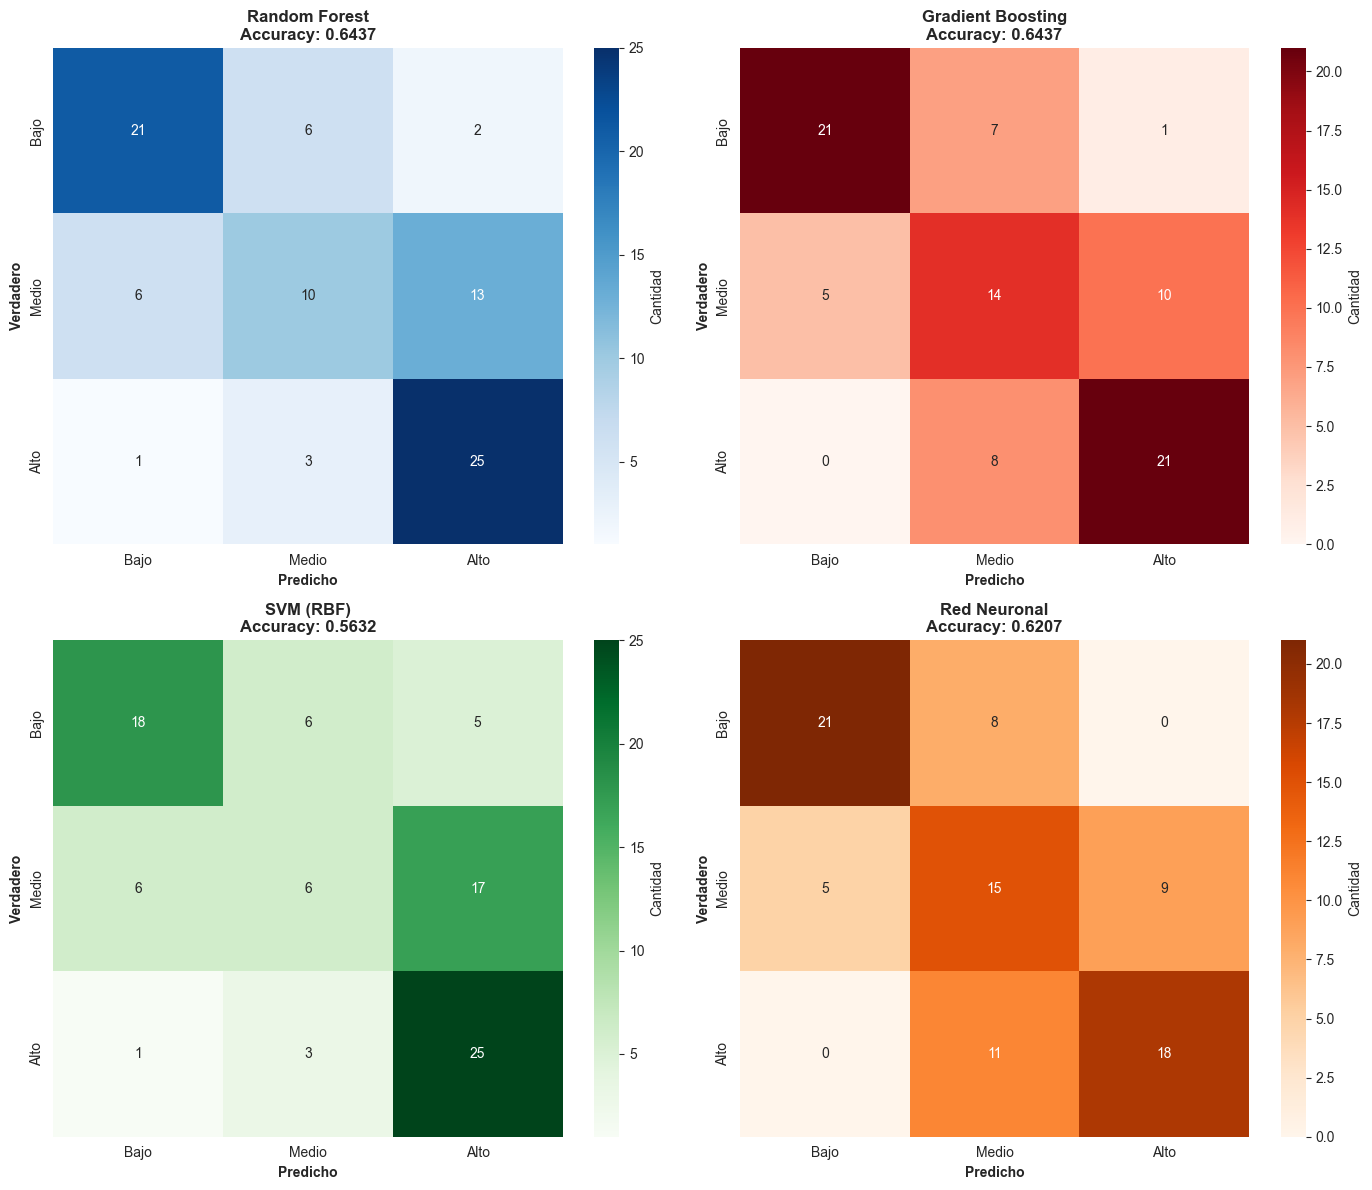

✓ Matrices de confusión generadas


In [8]:
# =============================
# MATRICES DE CONFUSIÓN
# =============================

cm_rf = confusion_matrix(y_test, y_test_pred_rf, labels=['Bajo', 'Medio', 'Alto'])
cm_gb = confusion_matrix(y_test, y_test_pred_gb, labels=['Bajo', 'Medio', 'Alto'])
cm_svm = confusion_matrix(y_test, y_test_pred_svm, labels=['Bajo', 'Medio', 'Alto'])
cm_nn = confusion_matrix(y_test, y_test_pred_nn, labels=['Bajo', 'Medio', 'Alto'])

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Random Forest
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0], 
            xticklabels=['Bajo', 'Medio', 'Alto'], yticklabels=['Bajo', 'Medio', 'Alto'],
            cbar_kws={'label': 'Cantidad'})
axes[0, 0].set_title(f'Random Forest\nAccuracy: {acc_test_rf:.4f}', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Verdadero', fontweight='bold')
axes[0, 0].set_xlabel('Predicho', fontweight='bold')

# Gradient Boosting
sns.heatmap(cm_gb, annot=True, fmt='d', cmap='Reds', ax=axes[0, 1],
            xticklabels=['Bajo', 'Medio', 'Alto'], yticklabels=['Bajo', 'Medio', 'Alto'],
            cbar_kws={'label': 'Cantidad'})
axes[0, 1].set_title(f'Gradient Boosting\nAccuracy: {acc_test_gb:.4f}', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Verdadero', fontweight='bold')
axes[0, 1].set_xlabel('Predicho', fontweight='bold')

# SVM
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Greens', ax=axes[1, 0],
            xticklabels=['Bajo', 'Medio', 'Alto'], yticklabels=['Bajo', 'Medio', 'Alto'],
            cbar_kws={'label': 'Cantidad'})
axes[1, 0].set_title(f'SVM (RBF)\nAccuracy: {acc_test_svm:.4f}', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Verdadero', fontweight='bold')
axes[1, 0].set_xlabel('Predicho', fontweight='bold')

# Red Neuronal
sns.heatmap(cm_nn, annot=True, fmt='d', cmap='Oranges', ax=axes[1, 1],
            xticklabels=['Bajo', 'Medio', 'Alto'], yticklabels=['Bajo', 'Medio', 'Alto'],
            cbar_kws={'label': 'Cantidad'})
axes[1, 1].set_title(f'Red Neuronal\nAccuracy: {acc_test_nn:.4f}', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Verdadero', fontweight='bold')
axes[1, 1].set_xlabel('Predicho', fontweight='bold')

plt.tight_layout()
plt.show()

print("✓ Matrices de confusión generadas")

### **Reflexión sobre Desempeño y Complejidad**

Los resultados revelan una relación no lineal entre complejidad del modelo y desempeño predictivo. En el conjunto de prueba, los cuatro modelos se distribuyen en un rango acotado de accuracy (56.3%–64.4%), lo que sugiere que el conjunto de datos es el principal limitante del desempeño, más que la metodología elegida.

Comparando con la actividad A2.2, donde el árbol de decisión individual logró ~71% de accuracy en entrenamiento, los ensambles demuestran mejor generalización real al obtener 64.4% en datos nuevos, con menos brecha entre entrenamiento y prueba que el árbol individual sobreajustado.

En cuanto a interpretabilidad, existe un intercambio fundamental: Random Forest y Gradient Boosting exponen la importancia de variables, permitiendo identificar que OVPT (hacinamiento), ANALF (analfabetismo) y PL_5000 (localidades pequeñas) son los indicadores más predictivos. SVM solo informa qué registros son vectores de soporte. Las redes neuronales son cajas negras que no permiten extraer explicaciones del proceso de decisión, lo que representa un costo significativo en contextos de política pública donde la transparencia es esencial.

---

## **7. Análisis Crítico y Conclusiones**

### **Ranking de Desempeño**

In [9]:
# =============================
# RANKING Y ANÁLISIS FINAL
# =============================

# Crear ranking basado en F1-Score (mejor balance entre precision/recall)
ranking = comparison_df.sort_values('F1-Score', ascending=False).reset_index(drop=True)
ranking['Rank'] = range(1, len(ranking) + 1)
ranking_display = ranking[['Rank', 'Modelo', 'F1-Score', 'Accuracy', 'Precision', 'Recall']].copy()

for col in ['F1-Score', 'Accuracy', 'Precision', 'Recall']:
    ranking_display[col] = ranking_display[col].apply(lambda x: f"{x:.4f}")

print("\n" + "="*100)
print("RANKING DE MODELOS (por F1-Score - métrica de balance)")
print("="*100)
display(ranking_display)

# Calcular diferencias porcentuales respecto al mejor
mejor_f1 = comparison_df['F1-Score'].max()
mejor_model = comparison_df[comparison_df['F1-Score'] == mejor_f1]['Modelo'].values[0]

print(f"\n✓ Mejor modelo: {mejor_model} (F1-Score: {mejor_f1:.4f})")
print(f"\nDiferencias relativas respecto al mejor:")

for idx, row in comparison_df.iterrows():
    if row['Modelo'] != mejor_model:
        diferencia = (mejor_f1 - row['F1-Score']) / mejor_f1 * 100
        print(f"  {row['Modelo']:25s}: {diferencia:6.2f}% inferior")

# Análisis de sobreajuste
print(f"\n" + "="*100)
print("ANÁLISIS DE SOBREAJUSTE (Gap entre Entrenamiento y Prueba)")
print("="*100)

gap_data = pd.DataFrame({
    'Modelo': ['Random Forest', 'Gradient Boosting', 'SVM', 'Red Neuronal'],
    'Gap Accuracy': [gap_rf, gap_gb, gap_svm, gap_nn],
    'Clasificación': [
        'Bajo' if gap_rf < 0.15 else 'Moderado' if gap_rf < 0.25 else 'Alto',
        'Bajo' if gap_gb < 0.15 else 'Moderado' if gap_gb < 0.25 else 'Alto',
        'Bajo' if gap_svm < 0.15 else 'Moderado' if gap_svm < 0.25 else 'Alto',
        'Bajo' if gap_nn < 0.15 else 'Moderado' if gap_nn < 0.25 else 'Alto'
    ]
})

gap_data['Gap %'] = gap_data['Gap Accuracy'].apply(lambda x: f"{x*100:.2f}%")

print(gap_data[['Modelo', 'Gap %', 'Clasificación']].to_string(index=False))
print("="*100)

print(f"\nInterpretación:")
print(f"  Gap < 15%  → Excelente generalización (no sobreaajusta)")
print(f"  Gap 15-25% → Moderado (algo de sobreajuste, pero controlado)")
print(f"  Gap > 25%  → Alto (considerable sobreajuste)")


RANKING DE MODELOS (por F1-Score - métrica de balance)


,Rank,Modelo,F1-Score,Accuracy,Precision,Recall
0,1,Gradient Boosting,0.6450,0.6437,0.6489,0.6437
1,2,Red Neuronal,0.6276,0.6207,0.6385,0.6207
2,3,Random Forest,0.6260,0.6437,0.6338,0.6437
3,4,SVM,0.5324,0.5632,0.5506,0.5632



✓ Mejor modelo: Gradient Boosting (F1-Score: 0.6450)

Diferencias relativas respecto al mejor:
  Random Forest            :   2.93% inferior
  SVM                      :  17.45% inferior
  Red Neuronal             :   2.70% inferior

ANÁLISIS DE SOBREAJUSTE (Gap entre Entrenamiento y Prueba)
           Modelo  Gap % Clasificación
    Random Forest 23.69%      Moderado
Gradient Boosting 27.17%          Alto
              SVM 13.83%          Bajo
     Red Neuronal 23.50%      Moderado

Interpretación:
  Gap < 15%  → Excelente generalización (no sobreaajusta)
  Gap 15-25% → Moderado (algo de sobreajuste, pero controlado)
  Gap > 25%  → Alto (considerable sobreajuste)


### **Reflexión sobre Resultados**

El análisis comparativo muestra que Gradient Boosting lidera con F1-Score de 0.6450, seguido por Red Neuronal (0.6276), Random Forest (0.6260) y SVM (0.5324). Sin embargo, las diferencias entre los tres primeros son de menos del 3%, lo que indica que todos capturan patrones similares en los datos.

El análisis de sobreajuste revela patrones distintos y significativos. SVM muestra el mejor perfil de generalización con una diferencia de solo 13.83%, aunque su desempeño absoluto en prueba es el más bajo. Esto sugiere que SVM, con los hiperparámetros actuales, posiblemente está subajustando encontró un modelo generalizable pero no suficientemente complejo para capturar todos los patrones relevantes. Random Forest y Red Neuronal presentan gaps moderados de 23.69% y 23.50%, indicando cierto sobreajuste controlado que es aceptable y típico en estos métodos. Gradient Boosting presenta el mayor sobreajuste con 27.17%, lo que explica parcialmente por qué, a pesar de ser el líder en prueba, su accuracy de entrenamiento 91.5% está muy lejos de su accuracy real 64.4%.

La pregunta clave en contextos de política pública de seguridad no es únicamente '¿cuál modelo es más preciso?' sino también '¿cuál modelo podemos explicar y defender ante tomadores de decisiones?' En ese sentido, Random Forest es la opción más equilibrada ya que logra 64.4% de accuracy con sobreajuste moderado, permite identificar explícitamente los indicadores más relevantes (OVPT, ANALF, PL_5000) y su proceso de decisión puede aproximarse de forma comprensible.

### **Conclusiones Finales**

Este análisis comparativo de cuatro metodologías avanzadas sobre el problema de predicción de criminalidad estatal en México permite extraer conclusiones robustas:

Desempeño general: Los cuatro modelos logran accuracy entre 56.3% y 64.4% en el conjunto de prueba —significativamente por encima del 33.3% de la predicción aleatoria, pero con margen de mejora. El techo de desempeño observado (~64%) sugiere que los indicadores de marginación disponibles capturan una parte importante, pero no completa, de la variabilidad en los niveles de criminalidad estatal. Variables adicionales (desigualdad de ingreso, presencia de fuerzas de seguridad, factores históricos) podrían incrementar sustancialmente la capacidad predictiva.

Elección del modelo: Gradient Boosting ofrece el mejor F1-Score (0.6450) pero con el mayor sobreajuste (27.17%). Random Forest representa la mejor combinación de desempeño (accuracy 64.4%, F1 0.6260), sobreajuste moderado (23.69%) e interpretabilidad total. SVM generaliza excepcionalmente bien pero tiene el desempeño absoluto más bajo, lo que lo posiciona como candidato para ajuste adicional de hiperparámetros.

Complejidad: La Red Neuronal, siendo la más compleja con 3,363 parámetros entrenables, no supera a métodos más simples. 

Aplicación práctica: Para un contexto real de política pública de seguridad en México, la recomendación sería utilizar Gradient Boosting como modelo predictivo principal por su desempeño superior, complementado con el análisis de importancia de variables de Random Forest para la comunicación de resultados a tomadores de decisiones. La información de que el hacinamiento (OVPT) es el predictor más importante con 12.5% de importancia, seguido por localidades pequeñas (PL_5000, 13.0%) y viviendas sin energía eléctrica (OVSAE, 15.9%), ofrece guías concretas para la mejora de programas sociales preventivos.